```quote
Every operation that creates a new tensor in forward pass needs a backward rule so the gradient can flow through it
```

1. The Tensor class. 

The mathematical difference between the scaler Value is that gradients are no longer numbers, they're arrays of same shape as the tensor. 
When tensor of different shapes interact, gradients must be summed back down to original shape. 

For C = A + B where B is broadcast (eg bias vector added to a batch). 
A shape = (N, D)
B shape = (D, )

$$\frac{\partial L}{\partial B_j} = \sum_{i=1}^{N} \frac{\partial L}{\partial C_{ij}}$$

i.e I need to sum the incoming gradient over the broadcasted axes. This is only the new idea here, the chain rule itself is identical to what I already implemented in micrograd. 

In [ ]:
import numpy as np
class Tensor:
    def __init__(self, data, _children=(), _op=''):
        self.data = np.array(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
    
    @property
    def shape(self):
        return self.data.shape
    
    def __repr__(self):
        return f"Tensor(data={self.data})"

    def _unbroadcast(self, grad, shape):
        # grad shape (3, ), target shape (). 
        # sums across the rows
        
        while grad.ndim > len(shape):
            grad = grad.sum(axis=0)
        
        # checks for 1 dimensions in target shape and sum across that axis.
        # if target shape is (1, 3) sums over that axis and keeps the dimension as (1, 3) 
        for i, dim in enumerate(shape):
            if dim == 1:
                grad = grad.sum(axis=i, keepdims=True)
        return grad

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += self._unbroadcast(out.grad, self.data.shape)
            other.grad += self._unbroadcast(out.grad, other.data.shape)
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += self._unbroadcast(out.grad * other.data, self.data.shape)
            other.grad += self._unbroadcast(out.grad * self.data, other.data.shape)
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other 
    
    def __matmul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data @ other.data, (self, other), '@')

        def _backward():
            self.grad += self._unbroadcast(out.grad @ np.swapaxes(other.data, -1, -2), self.data.shape)
            other.grad += self._unbroadcast(np.swapaxes(self.data, -1, -2) @ out.grad, other.data.shape)
        
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return other + (-self)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Tensor(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        
        return out
    
    def __getitem__(self, idx):
        out = Tensor(self.data[idx], (self, ), 'index')

        def _backward():
            g = np.zeros_like(self.data)
            np.add.at(g, idx, out.grad)
            self.grad += g
        out._backward = _backward
        return out

    
    def __abs__(self):
        out = Tensor(np.abs(self.data), (self, ), 'abs')

        def _backward():
            self.grad += np.sign(self.data) * out.grad
        out._backward = _backward

        return out
    
    def mean(self, axis=None, keepdims=False):
        n = self.data.size if axis is None else self.data.shape[axis]
        return self.sum(axis=axis, keepdims=keepdims) * (1.0 / n)

    def sum(self, axis=None, keepdims=False):
        out = Tensor(self.data.sum(axis=axis, keepdims=keepdims), (self, ), 'sum')

        def _backward():
            grad = out.grad
            if axis is not None and not keepdims:
                # restoring collapsed axis shape
                grad = np.expand_dims(grad, axis)
            
            # the partial derivative of out wrt to any input element is 1. 
            self.grad += np.ones_like(self.data) * grad
        
        out._backward = _backward
        return out
    
    def log(self):
        out = Tensor(np.log(self.data), (self, ), 'log')

        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        out = Tensor(np.exp(self.data), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad 

        out._backward = _backward

        return out 
    
    def clip(self, min_val, max_val):
        out = Tensor(np.clip(self.data, min_val, max_val), (self, ), 'clip')

        def _backward():
            mask = (self.data >= min_val) & (self.data <= max_val)
            self.grad += mask * out.grad
        out._backward = _backward 

        return out
    
    def max(self, axis = None, keepdims=False):
        out_data = np.max(self.data, axis=axis, keepdims=True)

        out = Tensor(np.squeeze(out_data, axis=axis)) if (axis is not None and not keepdims) else Tensor(out_data, (self, ), 'max')

        def _backward():
            grad = out.grad
            if axis is not None and not keepdims:
                grad = np.extend_dims(grad.data, axis=axis)
            
            #split gradient evenly among ties (row having same max,rare but in case)
            mask = (self.data == out_data)
            self.grad += mask * grad / (mask.sum(axis=axis, keepdims=True))
        
        out._backward = _backward

        return out
    
    
    
    def relu(self):
        out = Tensor(np.maximum(0, self.data), (self, ), 'ReLU')
        
        def _backward():
            self.grad += (out.data > 0) * out.grad
        
        out._backward = _backward
        return out
    
    def leakyrelu(self, alpha=0.01):
        out = Tensor(np.where(self.data > 0, self.data, alpha * self.data), (self, ), 'LeakyReLU')

        def _backward():
            self.grad += np.where(self.data > 0, 1.0, alpha) * out.grad
        out._backward = _backward

        return out
    
    def sigmoid(self):
        s = 1 / (1 + np.exp(-self.data))
        out = Tensor(s, (self, ), 'Sigmoid')

        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        t = np.tanh(self.data)
        out = Tensor(t, (self, ), 'Tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad 
        
        out._backward = _backward

        return out



    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = np.ones_like(self.data)
        for node in reversed(topo):
            node._backward()

        
        



In [4]:
a = Tensor([1.0, 2.0, 3.0])
b = Tensor(2.0)
c = b + a
d = a - b
e = -a + b
f = a**2
m = f.mean()
print(c)
print(d)
print(e)
print(f)
print(m)

Tensor(data=[3. 4. 5.])
Tensor(data=[-1.  0.  1.])
Tensor(data=[ 1.  0. -1.])
Tensor(data=[1. 4. 9.])
Tensor(data=4.666666666666666)


In [5]:
print(f"a shape: {a.shape}, b shape: {b.shape}")

a shape: (3,), b shape: ()


In [6]:
c.grad = np.array([1.0, 1.0, 1.0])
c._backward()
print(a.grad, b.grad)

[1. 1. 1.] 3.0


Since b was added to all 3 elements of a, it's gradient is the sum of all incoming gradients (1.0 + 1.0 + 1.0) = 3.0. 


In [7]:
d = Tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

e = Tensor([10.0, 20.0])
f = d + e
print("d shape", d.shape)
print("e shape", e.shape)
print("f shape", f.shape)
f

d shape (2, 2)
e shape (2,)
f shape (2, 2)


Tensor(data=[[11. 22.]
 [13. 24.]])

In [8]:
f.grad = np.array([
    [1.0, 2.0],
    [3.0, 4.0]
])

f._backward()

print("d grad: ", d.grad)
print("e grad: ", e.grad)

d grad:  [[1. 2.]
 [3. 4.]]
e grad:  [4. 6.]


here, 10.0 was added to both 1.0 and 3.0 so it must have gradient of both 1.0 and 3.0. (1.0 + 3.0 = 4.0)



In [9]:
g = Tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

h = Tensor([
    [10.0, 20.0, 30.0]
])

i = g + h
print("g shape: ", g.shape)
print("h shape: ", h.shape)
print("i shape: ", i.shape)

g shape:  (2, 3)
h shape:  (1, 3)
i shape:  (2, 3)


numpy did this while adding. 

$$i = \begin{bmatrix} 1.0 & 2.0 & 3.0 \\ 4.0 & 5.0 & 6.0 \end{bmatrix} + \begin{bmatrix} 10.0 & 20.0 & 30.0 \\ 10.0 & 20.0 & 30.0 \end{bmatrix} = \begin{bmatrix} 11.0 & 22.0 & 33.0 \\ 14.0 & 25.0 & 36.0 \end{bmatrix}$$

In [10]:
# suppose the incoming grad for i is. 
i.grad = np.array([
    [1.0, 1.0, 1.0],
    [2.0, 2.0, 2.0],
])

i._backward()

print("g grad: ", g.grad)
print("i grad: ", h.grad)

g grad:  [[1. 1. 1.]
 [2. 2. 2.]]
i grad:  [[3. 3. 3.]]


In [11]:
# a complex multi-dimensional tensor shape
A = Tensor(np.ones((2, 4, 3)))

B_data = np.array([
    [[10.0, 20.0, 30.0]],
    [[40.0, 50.0, 60.0]]
])

B = Tensor(B_data)

C = A + B

print("A shape: ", A.shape)
print("B shape: ", B.shape)
print("C shape: ", C.shape)

A shape:  (2, 4, 3)
B shape:  (2, 1, 3)
C shape:  (2, 4, 3)


In [12]:
A

Tensor(data=[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]])

In [13]:
C

Tensor(data=[[[11. 21. 31.]
  [11. 21. 31.]
  [11. 21. 31.]
  [11. 21. 31.]]

 [[41. 51. 61.]
  [41. 51. 61.]
  [41. 51. 61.]
  [41. 51. 61.]]])

In [14]:
# suppose upstream gradient is. 
C.grad = np.ones((2, 4, 3))
C._backward()

print("A grad: ", A.grad)
print("B grad: ", B.grad)

A grad:  [[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]]
B grad:  [[[4. 4. 4.]]

 [[4. 4. 4.]]]


2. Adding element-wise multiply, matrix multiply and backward() driver. 

- element-wise multiplication. 
suppose C = A*B. 

then $$\frac{\partial L}{\partial A} = \frac{\partial L}{\partial C} ⊙B $$ (then unboardcast)

- matrix multiply. 
Y = X @ W where X (N, D) and W (D, M) Y(N, M)

given upstream gradient $$\frac{\partial L}{\partial W} = X^{T} \frac{\partial L}{\partial Y}$$

$$\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} W^{T} $$

here shapes must work out together. 

dX must be (N, D). 
so W must be transposed. same goes for dW

# 1. Element-wise matrix multiplication and gradient flow

In [15]:
A = Tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

B  = Tensor([2.0, 3.0, 4.0])

C = A*B # element wise multiply. 

B is expanded to (1, 3) and then it is broadcasted to (2, 3) to match size of A. C has now shape (2, 3). 

suppose C.grad is all-ones matrix. 

In [16]:
C.grad = np.array([
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0]
])

C._backward()

print("A.grad: ", A.grad)
print("B.grad: ", B.grad)

A.grad:  [[2. 3. 4.]
 [2. 3. 4.]]
B.grad:  [5. 7. 9.]


When you look at the _backward driver code. 
here out.grad is C.grad. self is A and other is B. 
so dA = out.grad * B.data = (2, 3) * (3, ) = (2, 3) that matches with shape of A so no unbroadcasting is needed. 

Whereas. 
db = out.grad * A.data = (2, 3) * (2, 3) = (2, 3) but it is need to be (3, ). 
so the grad along dimension 2 must be accumulate. so unbroadcasting is needed. 

here look at the unbroadcast code now. 
grad = (2, 3), shape = (3, )
here first while condition match, grad has more dimensions. 
    so along axis=0, that is along dimension 2, values are added, that returns (3, ) has final output. 




# 2. Matrix multiplication & gradient flow

In [17]:
A = Tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
]) # (2, 3)

B  = Tensor([
    [2.0, 3.0],
    [4.0, 5.0],
    [6.0, 7.0]
]) # (3, 2)

# both matrices' inner dim matches so they can be multiplied. 

C = A @ B # has shape (2, 2). 

print("C.shape: ", C.shape)
print("C.data:\n", C.data)


C.shape:  (2, 2)
C.data:
 [[28. 34.]
 [64. 79.]]


In [18]:
# lets assume C.grad to be
C.grad = np.array([
    [1.0, 1.0],
    [1.0, 1.0]
])
C._backward()

print("A.grad: \n", A.grad)
print("B.grad: \n", B.grad)

A.grad: 
 [[ 5.  9. 13.]
 [ 5.  9. 13.]]
B.grad: 
 [[5. 5.]
 [7. 7.]
 [9. 9.]]


If you do that on paper, you will get the same grad as above.

Note: mat mul works for 3D/4D tensors, because @ automatically handles batched matrix multiplication broadcasting across higher dimensions. 

but backward pass fails. 
Below code document this limitation. Take a look!

In [19]:
X_3d  = Tensor(np.ones((2, 3, 4))) # 2 batch of (3, 4) matrix
W_3d = Tensor(np.ones((2, 4, 5))) # 2 batch of (4, 5) matrix

Y_3d = X_3d @ W_3d

print("Y_3d.shape: ", Y_3d.shape)
print("Y_3d.data: \n", Y_3d.data)

try:
    loss = Y_3d.sum()
    print("loss: ", loss)
    loss.backward()
    print("X_3d.grad shape: ", X_3d.grad.shape)
except Exception as e:
    print("Backward pass fails as expected")
    print("error: ", str(e))

Y_3d.shape:  (2, 3, 5)
Y_3d.data: 
 [[[4. 4. 4. 4. 4.]
  [4. 4. 4. 4. 4.]
  [4. 4. 4. 4. 4.]]

 [[4. 4. 4. 4. 4.]
  [4. 4. 4. 4. 4.]
  [4. 4. 4. 4. 4.]]]
loss:  Tensor(data=120.0)
X_3d.grad shape:  (2, 3, 4)


The reason it fails, while dX_3d = loss.grad(2, 3, 5) @ W_3d(2, 4, 5)(T) 
W_3d is transpose along all axis (2, 4, 5) -> (5, 4, 2) and thus we get "size 4 is different from 5" value error. 

so instead of swapping the matrix axes to (2, 5, 4) using np.swapaxes(W, -1, -2). 

also what if the sample size or batch size is broadcasted while computing loss? 
suppose X_3d has (2, 3, 4) and W_3d has (1, 4, 5) then, 
numpy does obtain (2, 3, 5) result. But backward pass fails. 
dW_3d grad will have (assume above fix is applied) shape (2, 4, 5) but W_3d must have target shape of (1, 4, 5) so need to perform unbroadcast here. 

So this is fixed by the intended code above in the __matmul__ operation. 
now the above code is working as expected. 

# 3. nn.Module, nn.Parameter, nn.Linear

Parameter is just a Tensor with a special marker so Module can auto-discover it. 

Module.parameters() walks self.__dict__, collecting any Parameters and recursing into sub-Modules. 

Here how the weights and the baises are being initialized is very important. 

$$W, b \sim u(-\frac{1}{\sqrt{D_{in}}}, \frac{1}{\sqrt{D_{in}}})$$

this keeps the variance of activations roughly stable across layers at initialization(avoids vanishing/exploding early on)

In [3]:
class Parameter(Tensor):
    def __init__(self, data):
        super().__init__(data)

class Module:
    # returns a list of individual Parameter tensor objects, not the total count of scalar numerical weights.
    def parameters(self):
        params = []
        for attr in vars(self).values():
            if isinstance(attr, Parameter):
                params.append(attr)
            elif isinstance(attr, Module):
                params.extend(attr.parameters())
            elif isinstance(attr, (list, tuple)):
                for item in attr:
                    if isinstance(item, Module):
                        params.extend(item.parameters())
        return params
    
    def zero_grad(self):
        for p in self.parameters():
            p.grad = np.zeros_like(p.data)
    
    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)
    
    def forward(self, *args, **kwargs):
        raise NotImplementedError

class Linear(Module):
    def __init__(self, din, dout, bias=True):
        bound = 1 / np.sqrt(din)
        self.weight = Parameter(np.random.uniform(-bound, bound, (din, dout)))
        self.bias = Parameter(np.random.uniform(-bound, bound, (dout, ))) if bias else None
    
    def forward(self, x):
        out = x @ self.weight
        if self.bias is not None:
            out = out + self.bias
        return out
    
    def __repr__(self):
        in_f, out_f = self.weight.data.shape
        return f"Linear(in_features={in_f}, out_features={out_f})"


In [21]:
np.random.seed(0)

layer = Linear(3, 4)
print(layer)

Linear(in_features=3, out_features=4)


In [22]:
vars(layer).values()

dict_values([Tensor(data=[[ 0.05636498  0.24847928  0.11866093  0.05182664]
 [-0.08815584  0.16846401 -0.07206808  0.45238049]
 [ 0.53539164 -0.13459014  0.33685506  0.03336498]]), Tensor(data=[ 0.07857109  0.49143667 -0.49532489 -0.47674202])])

In [23]:
print("layer.weight: \n", layer.weight.data)
print("layer.bias: \n", layer.bias.data)
print("num params: ", len(layer.parameters()))
print("total individual weights: ", sum(p.data.size for p in layer.parameters()))

layer.weight: 
 [[ 0.05636498  0.24847928  0.11866093  0.05182664]
 [-0.08815584  0.16846401 -0.07206808  0.45238049]
 [ 0.53539164 -0.13459014  0.33685506  0.03336498]]
layer.bias: 
 [ 0.07857109  0.49143667 -0.49532489 -0.47674202]
num params:  2
total individual weights:  16


In [24]:
x = Tensor(np.random.randn(2, 5, 3))
y = layer(x)

print("output shape: ", y.shape)

output shape:  (2, 5, 4)


In [25]:
loss = y.sum()
print("loss: ", loss)
loss.backward()

print("weight.grad shape: ", layer.weight.grad.shape)
print("bias.grad shape: ", layer.bias.grad.shape)

loss:  Tensor(data=-2.7348525072291485)
weight.grad shape:  (3, 4)
bias.grad shape:  (4,)


# 4. activation functions: 

Relu: 

$$f(x) = max(0, x)$$

sigmoid:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

tanh:

$$tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

leakyrelu:
$$
f(x) = \begin{cases} x & x > 0 \\ \alpha x & x \le 0 \end{cases}
$$



In [4]:
class ReLU(Module):
    def forward(self, x):
        return x.relu()

class Sigmoid(Module):
    def forward(self, x):
        return x.sigmoid()

class Tanh(Module):
    def forward(self, x):
        return x.tanh()

class LeakyReLU(Module):
    def __init__(self, alpha=0.01):
        self.alpha = alpha
    def forward(self, x):
        return x.leakyrelu(self.alpha)

In [27]:
X = Tensor([
    [
        [1.0, 2.0, 3.0],
        [3.0, 4.0, 5.0]
    ],

    [
        [2.0, 3.0, 4.0],
        [4.0, 5.0, 6.0]
    ]
])

print("X.shape: ", X.shape)

layer = Linear(X.shape[-1], 4)

print(layer)

X.shape:  (2, 2, 3)
Linear(in_features=3, out_features=4)


In [28]:
y = layer(X)
print(y.shape)

(2, 2, 4)


In [29]:
y

Tensor(data=[[[-0.61420646 -2.53055093  0.49823053 -2.69990829]
  [ 0.07965713 -4.91913778  0.10913599 -4.90788495]]

 [[-0.26727467 -3.72484435  0.30368326 -3.80389662]
  [ 0.42658892 -6.1134312  -0.08541129 -6.01187328]]])

In [30]:
relu_mod = ReLU()

relu_mod(y)

Tensor(data=[[[0.         0.         0.49823053 0.        ]
  [0.07965713 0.         0.10913599 0.        ]]

 [[0.         0.         0.30368326 0.        ]
  [0.42658892 0.         0.         0.        ]]])

relu zero out all negative numbers and kept te positive number as it is. 

In [31]:
sigmoid_mod = Sigmoid()
sigmoid_mod(y)

Tensor(data=[[[0.35110025 0.07374401 0.62204341 0.06297877]
  [0.51990376 0.00725244 0.52725695 0.00733391]]

 [[0.43357628 0.02354893 0.57534267 0.02179803]
  [0.60505884 0.00220806 0.47866015 0.00244351]]])

sigmoid output is squased into (0, 1). 

In [32]:
tanh_mod = Tanh()
tanh_mod(y)

Tensor(data=[[[-0.54708136 -0.98740271  0.46072443 -0.99100581]
  [ 0.07948907 -0.99989327  0.10870475 -0.99989084]]

 [[-0.26108709 -0.99883743  0.29467967 -0.99900736]
  [ 0.40246668 -0.99999021 -0.0852042  -0.999988  ]]])

the output is ranged in (-1, 1).

In [33]:
leaky_relu_mod = LeakyReLU()
leaky_relu_mod(y)

Tensor(data=[[[-0.00614206 -0.02530551  0.49823053 -0.02699908]
  [ 0.07965713 -0.04919138  0.10913599 -0.04907885]]

 [[-0.00267275 -0.03724844  0.30368326 -0.03803897]
  [ 0.42658892 -0.06113431 -0.00085411 -0.06011873]]])

the leaky relu is smoother than relu here. as the negative numbers are not zero out. 

In [34]:
x = Tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

for name, fn in [('relu', x.relu), ('sigmoid', x.sigmoid), ('tanh', x.tanh), ('leaky_relu', x.leakyrelu)]:
    out = fn()
    print(out.sum())
    out.sum().backward()
    print(f"{name:10s} out={out.grad} grad={x.grad}")
    x.grad = np.zeros_like(x.data) # reset grad between tests. 

Tensor(data=2.5)
relu       out=[1. 1. 1. 1. 1.] grad=[0. 0. 0. 1. 1.]
Tensor(data=2.5)
sigmoid    out=[1. 1. 1. 1. 1.] grad=[0.10499359 0.23500371 0.25       0.23500371 0.10499359]
Tensor(data=0.0)
tanh       out=[1. 1. 1. 1. 1.] grad=[0.07065082 0.78644773 1.         0.78644773 0.07065082]
Tensor(data=2.475)
leaky_relu out=[1. 1. 1. 1. 1.] grad=[0.01 0.01 0.01 1.   1.  ]


In the above output. the grad for -2.0 is 0 and for other numbers <=0 as expected. 

for sigmoid, grad is larger near x=0, as it is steeper near x = 0. and grad is near zero at extremes x. 

tanh is same also, grad is larger near x = 0, and near zero at extreme x. 

leaky relu is alpha times for x <= 0 and 1 for x > 0.

# Loss 1: MSE(Mean Squared Error)

for predictions $$L = \frac{1}{N} \sum_{i=1}^{N}(\hat{y_i} - y_i)^2$$

gradient w.r.t prediction. 

$$\frac{\partial{L}}{\partial{\hat{y}}} = \frac{2}{N}(\hat{y_i} - y_i)$$

In [5]:
def mse_loss(y_hat, y):
    y = y if isinstance(y, Tensor) else Tensor(y)
    diff = y_hat - y
    return (diff ** 2).mean()

class MSELoss(Module):
    def forward(self, y_hat, y):
        return mse_loss(y_hat, y)


In [36]:
y_hat = Tensor([2.0, 0.5, 4.0])
y = Tensor([3.0, 0.0, 2.0])

loss = mse_loss(y_hat, y)
loss.backward()

print("loss: ", loss.data)
print("grad: ", y_hat.grad)

N = 3
expected_grad = (2.0/N) * (y_hat.data - y.data)
print("matches formula: ", np.allclose(y_hat.grad, expected_grad))

loss:  1.75
grad:  [-0.66666667  0.33333333  1.33333333]
matches formula:  True


# Loss 2: Binary Cross-Entropy Loss

$$L = \frac{1}{N}\sum_{i=1}^{N}[y_ilog(p_i) + (1 - y_i)log(1 - p_i)]$$


gradient w.r.t pi. 

$$\frac{\partial L}{\partial p_i} = \frac{1}{N}(\frac{y_i}{p_i} + \frac{1 - y_i}{1 - p_i})$$

numerical stabality issue if pi approaches to 0. 
so it is clip into [eps, 1 - eps] range. 

In [6]:
def bce_loss(y_hat, y, eps=1e-7):
    y = y if isinstance(y, Tensor) else Tensor(y)
    p = y_hat.clip(eps, 1 - eps)
    losses = y*p.log() + (Tensor(1.0) - y)*(Tensor(1.0) - p).log()
    return -losses.mean()

class BCELoss(Module):
    def forward(self, y_hat, y):
        bce_loss(y_hat, y)

In [38]:
y_hat = Tensor([0.9, 0.1, 0.8, 0.4])
y = Tensor([1.0, 0.0, 1.0, 0.0])
loss = bce_loss(y_hat, y)
loss.backward()
print("loss: ", loss.data)
print("grad: ", y_hat.grad)

n = 4
p = y_hat.data
expected_grad = (1.0 / N) * (p - y.data) / (p * (1 - p))
print("loss:", loss.data)
print("actual grad:  ", y_hat.grad)
print("expected grad:", expected_grad)
print("max abs diff: ", np.max(np.abs(y_hat.grad - expected_grad)))
print("matches formula:", np.allclose(y_hat.grad, expected_grad))

loss:  0.23617255159896325
grad:  [-0.27777778  0.27777778 -0.3125      0.41666667]
loss: 0.23617255159896325
actual grad:   [-0.27777778  0.27777778 -0.3125      0.41666667]
expected grad: [-0.37037037  0.37037037 -0.41666667  0.55555556]
max abs diff:  0.1388888888888889
matches formula: False


Numerically stable BCE with logits. 

In [7]:
def bce_with_logits_loss(z, y):
    y = y if isinstance(y, Tensor) else Tensor(y)

    losses = z.relu() - z * y  + (1.0 + (-abs(z)).exp()).log()

    return losses.mean()

class BCEWithLogitsLoss(Module):
    def forward(self, z, y):
        return bce_with_logits_loss(z, y)

In [40]:
z = Tensor([0.9, 0.1, 0.8, 0.4])
y = Tensor([1.0, 0.0, 1.0, 0.0])

# 1. Compute losses
p = z.sigmoid()
loss_a = bce_loss(p, y)
loss_b = bce_with_logits_loss(z, y)

print("sigmoid + clip:     ", loss_a.data)
print("raw logits. stable: ", loss_b.data)
print("close:             ", np.allclose(loss_a.data, loss_b.data))

# 2. Reset z.grad to zero before running backward on loss_b!
z.grad = np.zeros_like(z.data)
# 3. Backward pass on the stable logits loss
loss_b.backward()

# 4. Check against manual gradient
manual_grad = (p.data - y.data) / len(z.data)

print("z.grad:          ", z.grad)
print("manual gradient: ", manual_grad)
print("grad matches:    ", np.allclose(z.grad, manual_grad))

sigmoid + clip:      0.5924166132883473
raw logits. stable:  0.5924166132883473
close:              True
z.grad:           [-0.07226262  0.1312448  -0.07750638  0.14967192]
manual gradient:  [-0.07226262  0.1312448  -0.07750638  0.14967192]
grad matches:     True


In [41]:
A = Tensor([
    [1, 2, 3],
    [4, 8, 8]
])

print("A.shape: ", A.shape)
axis = None
keepdims = False
out_data = np.max(A.data, axis=axis, keepdims=True)
print("out_data: ", out_data)
mask = (A.data == out_data)
print("mask: \n",  mask)

print("mask sum: ", mask.sum(axis=axis, keepdims=True))
out = Tensor(np.squeeze(out_data, axis=axis)) if (axis is not None and not keepdims) else Tensor(out_data, (A, 
), 'max')

print("out: ", out.data)
axis = 1
keepdims = False

out_data = np.max(A.data, axis=axis, keepdims=True)
out = Tensor(np.squeeze(out_data, axis=axis)) if (axis is not None and not keepdims) else Tensor(out_data, (A, 
), 'max')

print("out_data: ", out.data)





A.shape:  (2, 3)
out_data:  [[8.]]
mask: 
 [[False False False]
 [False  True  True]]
mask sum:  [[2]]
out:  [[8.]]
out_data:  [3. 8.]


In [42]:
B = Tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

y = B[1][[0, 1]]

y.backward()

print("B.grad", B.grad)

B.grad [[0. 0. 0.]
 [1. 1. 0.]]


## 1. Cross-entropy loss

In [8]:
def cross_entropy_loss(z, y):
    y_idx = y.data.astype(int) if isinstance(y, Tensor) else np.array(y, dtype=int)
    N = z.shape[0]
    
    m = z.max(axis=1, keepdims=True)
    shifted = z - m

    log_sum_exp = shifted.exp().sum(axis=1, keepdims=True).log()
    log_probs = shifted - log_sum_exp

    row_idx = np.arange(N)
    picked = log_probs[row_idx, y_idx]

    return -picked.mean()

class CrossEntropyLoss(Module):
    def forward(self, z, y):
        return cross_entropy_loss(z, y)

In [44]:
np.random.seed(0)
z = Tensor(np.random.randn(4, 3))
print("z(logits): \n", z)

y = np.array([0, 2, 1, 1])

loss = cross_entropy_loss(z, y)
loss.backward()

print("loss: ", loss.data)
print("grad: ", z.grad)



z(logits): 
 Tensor(data=[[ 1.76405235  0.40015721  0.97873798]
 [ 2.2408932   1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721 -0.10321885]
 [ 0.4105985   0.14404357  1.45427351]])
loss:  1.929407582261248
grad:  [[-0.10394119  0.03734183  0.06659936]
 [ 0.1446372   0.09957323 -0.24421043]
 [ 0.14870574 -0.20057167  0.05186593]
 [ 0.05428118 -0.20841986  0.15413867]]


In [45]:
# hand compute expected grads. 
z_shift = z.data - z.data.max(axis=1, keepdims=True)

p = np.exp(z_shift) / np.exp(z_shift).sum(axis=1, keepdims=True)
one_hot = np.zeros_like(p)
one_hot[np.arange(4), y] = 1
expected_grad =  (p - one_hot) / 4

print("matches formula: ", np.allclose(z.grad, expected_grad))

matches formula:  True


An extreme-logit stability check:

In [46]:
z_extreme = Tensor([[1000.0, 1.0, 0.0]])
loss_extreme = cross_entropy_loss(z_extreme, [0])

print("extreme loss (finite): ", loss_extreme.data) # it should be -0.0

extreme loss (finite):  -0.0


Let's validate the whole pipeline end-to-end on a real dataset. 

We have: 

1. Tensor
2. Module
3. Linear
4. activations. 
5. losses. 

The only missing piece is a way to chain layers together, just like how pytorch nn.Sequential does. 

For updating the weights of the model vanilla gradient descent is used for now. 

In [9]:
class Sequential(Module):
    def __init__(self, *layers):
        self.layers = list(layers)
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def __repr__(self):
        return "Sequential(\n  " + "\n ".join(str(l) for l in self.layers) + "\n)"
        

Text(0.5, 1.0, 'make_moons dataset')

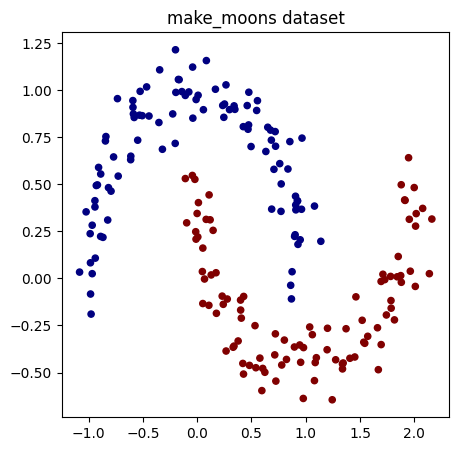

In [10]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

np.random.seed(1137)

X,y = make_moons(n_samples=200, noise=0.1)
y = y.astype(np.float64)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='jet', s=20)
plt.title("make_moons dataset")

In [49]:
model = Sequential(
    Linear(2, 16),
    ReLU(),
    Linear(16, 16),
    ReLU(),
    Linear(16, 1),
)

print(model)
print("num params: ", len(model.parameters()))


Sequential(
  Linear(in_features=2, out_features=16)
 Linear(in_features=16, out_features=16)
 Linear(in_features=16, out_features=1)
)
num params:  6


In [50]:
X_t = Tensor(X)
y_t = Tensor(y)


loss_fn = BCEWithLogitsLoss()

lr = 0.1

losses = []

for epoch in range(800):
    z = model(X_t) # (200, 1)
    z = z[:, 0]  # flatten to (200, )
    loss = loss_fn(z, y_t)
    model.zero_grad()
    loss.backward()

    for p in model.parameters():
        p.data -= lr * p.grad
    
    losses.append(loss.data)

    if epoch % 20 == 0:
        preds = (1/(1 + np.exp(-z.data)) > 0.5).astype(float)
        acc = (preds == y).mean()

        print(f"epoch {epoch:3d}    loss {loss.data:.4f}    acc {acc*100:.1f}%")

epoch   0    loss 0.6828    acc 50.0%
epoch  20    loss 0.6355    acc 62.5%
epoch  40    loss 0.5615    acc 84.5%
epoch  60    loss 0.4749    acc 86.0%
epoch  80    loss 0.3961    acc 86.5%
epoch 100    loss 0.3369    acc 87.5%
epoch 120    loss 0.3010    acc 87.5%
epoch 140    loss 0.2803    acc 88.0%
epoch 160    loss 0.2682    acc 88.0%
epoch 180    loss 0.2605    acc 88.0%
epoch 200    loss 0.2551    acc 88.5%
epoch 220    loss 0.2508    acc 89.0%
epoch 240    loss 0.2469    acc 88.5%
epoch 260    loss 0.2431    acc 89.5%
epoch 280    loss 0.2391    acc 89.5%
epoch 300    loss 0.2343    acc 89.5%
epoch 320    loss 0.2267    acc 89.5%
epoch 340    loss 0.2185    acc 90.5%
epoch 360    loss 0.2098    acc 90.5%
epoch 380    loss 0.2005    acc 91.5%
epoch 400    loss 0.1909    acc 91.5%
epoch 420    loss 0.1808    acc 91.5%
epoch 440    loss 0.1705    acc 92.0%
epoch 460    loss 0.1602    acc 94.0%
epoch 480    loss 0.1497    acc 95.0%
epoch 500    loss 0.1392    acc 95.5%
epoch 520   

Text(0.5, 1.0, 'training loss')

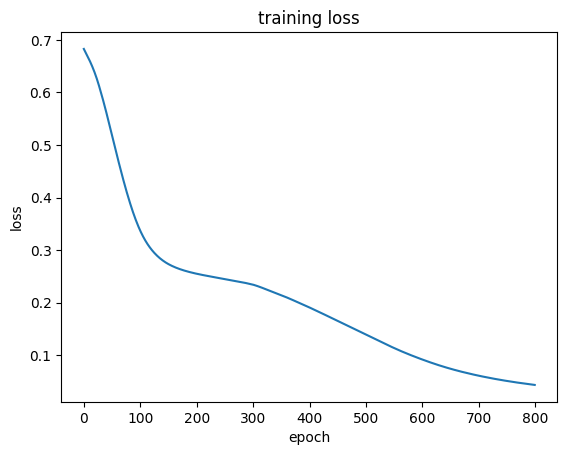

In [51]:
plt.figure()
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("training loss")


Text(0.5, 1.0, 'decision boundary')

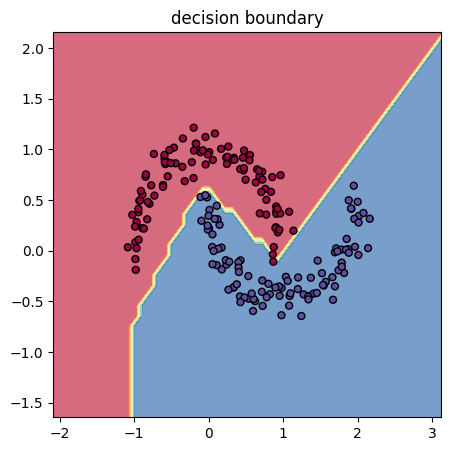

In [52]:
h = 0.1
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
grid = np.c_[xx.ravel(), yy.ravel()]

logits_grid = model(Tensor(grid))[:,0]
Z = (logits_grid.data > 0).astype(float).reshape(xx.shape)

plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral, edgecolors='k', s=25)
plt.title("decision boundary")

## Moving average of gradients. SGD (Momentum)

In [20]:
class Optimizer:
    def __init__(self, parameters):
        self.parameters = list(parameters)
    
    def zero_grad(self):
        for p in self.parameters:
            p.grad = np.zeros_like(p.data)
    def step(self):
        raise NotImplementedError

class SGD(Optimizer):
    def __init__(self, parameters, lr=0.01, momentum=0.0, weight_decay=0.0):
        super().__init__(parameters)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [np.zeros_like(p.data) for p in self.parameters]
        self.weight_decay = weight_decay
    
    def step(self):
        for p, v in zip(self.parameters, self.velocities):
            grad = p.grad + self.weight_decay * p.data
            if self.momentum > 0.0:
                v[:] = self.momentum * v + (1 - self.momentum) * grad
                p.data -= self.lr * v
            else:
                p.data -= self.lr * grad

In [54]:
np.random.seed(1337)
model = Sequential(
    Linear(2, 16), ReLU(),
    Linear(16, 16), ReLU(),
    Linear(16, 1),
)
loss_fn = BCEWithLogitsLoss()
optimizer = SGD(model.parameters(), lr=0.5, momentum=0.9)

X_t = Tensor(X)
y_t = Tensor(y)
losses = []

for epoch in range(400):
    logits = model(X_t)[:, 0]
    loss = loss_fn(logits, y_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)
    if epoch % 20 == 0:
        preds = (1/(1+np.exp(-logits.data)) > 0.5).astype(float)
        acc = (preds == y).mean()
        print(f"epoch {epoch:3d}  loss {loss.data:.4f}  acc {acc*100:.1f}%")

epoch   0  loss 0.6968  acc 50.0%
epoch  20  loss 0.5922  acc 83.0%
epoch  40  loss 0.2804  acc 87.0%
epoch  60  loss 0.2367  acc 89.5%
epoch  80  loss 0.2055  acc 91.0%
epoch 100  loss 0.1720  acc 92.5%
epoch 120  loss 0.1320  acc 95.0%
epoch 140  loss 0.0915  acc 96.0%
epoch 160  loss 0.0610  acc 99.0%
epoch 180  loss 0.0418  acc 99.5%
epoch 200  loss 0.0305  acc 100.0%
epoch 220  loss 0.0236  acc 100.0%
epoch 240  loss 0.0192  acc 100.0%
epoch 260  loss 0.0159  acc 100.0%
epoch 280  loss 0.0135  acc 100.0%
epoch 300  loss 0.0117  acc 100.0%
epoch 320  loss 0.0103  acc 100.0%
epoch 340  loss 0.0091  acc 100.0%
epoch 360  loss 0.0082  acc 100.0%
epoch 380  loss 0.0074  acc 100.0%


Text(0.5, 1.0, 'decision boundary')

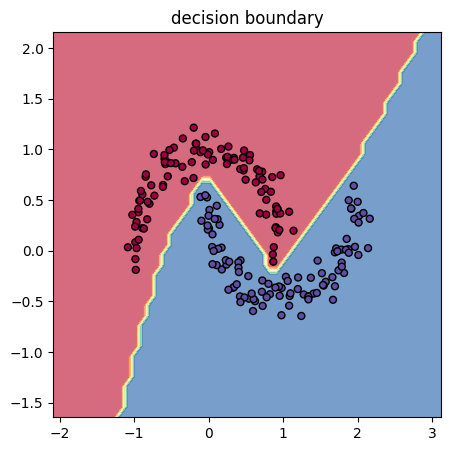

In [55]:
h = 0.1
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
grid = np.c_[xx.ravel(), yy.ravel()]

logits_grid = model(Tensor(grid))[:,0]
Z = (logits_grid.data > 0).astype(float).reshape(xx.shape)

plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral, edgecolors='k', s=25)
plt.title("decision boundary")

## RMSProp.

In [12]:
class RMSProp(Optimizer):
    def __init__(self,  parameters, beta=0.99, lr=0.01, eps=1e-8):
        super().__init__(parameters)
        self.beta = beta
        self.eps =  eps
        self.lr = lr

        self.s = [np.zeros_like(p.data) for p in self.parameters]


    def step(self):
        for p, s in zip(self.parameters, self.s):
            s[:] = self.beta * s + (1 - self.beta) * (p.grad ** 2)

            p.data -= self.lr * p.grad / ( np.sqrt(s) +  self.eps)




In [13]:
class Adam(Optimizer):
    def __init__(self, parameters, beta1=0.9, beta2=0.999, eps=1e-8, lr=0.001):
        super().__init__(parameters)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.lr = lr
        self.t = 0

        self.v = [np.zeros_like(p.data) for p in self.parameters]
        self.s = [np.zeros_like(p.data) for p in self.parameters]
    
    def step(self):
        self.t += 1

        for p, v, s in zip(self.parameters, self.v, self.s):
            v[:] = self.beta1 * v  + ( 1 - self.beta1) * p.grad
            s[:] = self.beta2 * s + (1 - self.beta2) * (p.grad ** 2)

            # bias correction

            v_corrected = v / ( 1 - self.beta1 ** self.t)
            s_corrected = s / (1 - self.beta2 ** self.t)

            p.data -= self.lr * (v_corrected / (np.sqrt(s_corrected) + self.eps))

            


SGD (plain)          final loss 0.0120  acc 100.0%
SGD + momentum       final loss 0.0118  acc 100.0%
RMSProp              final loss 0.0007  acc 100.0%
Adam                 final loss 0.0000  acc 100.0%


Text(0.5, 1.0, 'optimizer comparison on make_moons')

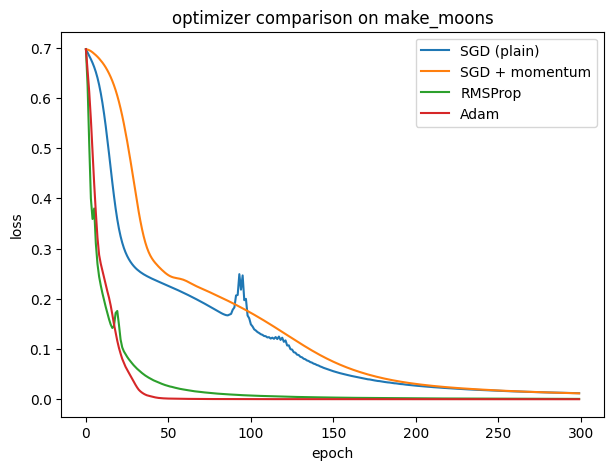

In [16]:
def train(optimizer_fn, label, epochs=300, seed=1337):
    np.random.seed(seed)
    model = Sequential(
        Linear(2, 16), ReLU(),
        Linear(16, 16), ReLU(),
        Linear(16, 1),
    )
    loss_fn = BCEWithLogitsLoss()
    optimizer = optimizer_fn(model.parameters())

    X_t, y_t = Tensor(X), Tensor(y)
    losses = []
    for epoch in range(epochs):
        logits = model(X_t)[:, 0]
        loss = loss_fn(logits, y_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.data)

    preds = (1/(1+np.exp(-logits.data)) > 0.5).astype(float)
    acc = (preds == y).mean()
    print(f"{label:20s} final loss {loss.data:.4f}  acc {acc*100:.1f}%")
    return losses

results = {}
results['SGD (plain)']      = train(lambda p: SGD(p, lr=0.5), 'SGD (plain)')
results['SGD + momentum']   = train(lambda p: SGD(p, lr=0.5, momentum=0.9), 'SGD + momentum')
results['RMSProp']          = train(lambda p: RMSProp(p, lr=0.01), 'RMSProp')
results['Adam']             = train(lambda p: Adam(p, lr=0.05), 'Adam')

plt.figure(figsize=(7,5))
for label, losses in results.items():
    plt.plot(losses, label=label)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("optimizer comparison on make_moons")

L1/L2 weight decay. 

why regularization:
without any penalty, weights are free to grow to fit noise in the training data. regularization adds a penalty term to loss that discourages large weights. 

$$L_{total} = L_{data} + \lambda R(\theta)$$

L2(weight decay) penalizes the squeared magnitude 

$$R_{L2}(\theta) = \frac{1}{2} \sum_i (\theta_i)^2$$

so, 
$$\theta = \theta - \eta(g_t - \lambda\theta = (1 - \eta\lambda)\theta - \eta g_t$$

so every step no matter what the gradient is, weight shrink a little. 

L1 penalizes absolute magnitude, and tends to push weight to exactly zero (sparsity). 

$$R_{L1(\theta)} = \sum_i | \theta_i | $$

In [14]:
def l2_penalty(parameters, lam=1e-4):
    total = Tensor(0.0)
    for p in parameters:
        total = total + (p ** 2).sum()
    return lam * 0.5 * total

def l1_penalty(parameters, lam=1e-4):
    total = Tensor(0.0)
    for p in parameters:
        total = total + abs(p).sum()
    return lam * total

In [21]:
def train_with_reg(weight_decay=0.0, l2_lam=0.0, epochs=400, seed=1337):
    np.random.seed(seed)
    model = Sequential(
        Linear(2, 16), ReLU(),
        Linear(16, 16), ReLU(),
        Linear(16, 1),
    )
    loss_fn = BCEWithLogitsLoss()
    optimizer = SGD(model.parameters(), lr=0.5, momentum=0.9, weight_decay=weight_decay)

    X_t, y_t = Tensor(X), Tensor(y)

    for epoch in range(epochs):
        logits = model(X_t)[:, 0]
        loss = loss_fn(logits, y_t)
        if l2_lam > 0:
            loss  = loss + l2_penalty(model.parameters(), lam=l2_lam)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    preds = (1/(1 + np.exp(-logits.data)) > 0.5).astype(float)
    acc = (preds == y).mean()
    avg_weight_norm = np.mean([np.linalg.norm(p.data) for p in model.parameters()])
    print(f"wd={weight_decay}, l2_lam={l2_lam} loss {loss.data:.4f} acc {acc*100:.4f} avg |w|={avg_weight_norm:.4f}")

train_with_reg(weight_decay=0.0)
train_with_reg(weight_decay=0.01) # optimizer-coupled L2
train_with_reg(l2_lam=0.01) # loss-level L2. 


wd=0.0, l2_lam=0.0 loss 0.0068 acc 100.0000 avg |w|=3.0168
wd=0.01, l2_lam=0.0 loss 0.0664 acc 99.0000 avg |w|=1.9101
wd=0.0, l2_lam=0.01 loss 0.2209 acc 99.0000 avg |w|=1.9101
